### prep chai array-like

In [20]:
import pandas as pd
import yaml
from pathlib import Path

YAML_PATH = "/home/bri/pymol/EDA/static/metric_directions.yaml"
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/snir_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CSV_PATH =  "/home/bri/pymol/EDA/static/snir_outputs/merged_snir.csv"
scores_df = pd.read_csv(CSV_PATH)

#scores_df.head()

### prep chai array-like

In [21]:
chai_df = scores_df[['sample', 'chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']]
chai_df.to_csv(OUTPUT_DIR / 'chai_matrices.csv', index=False)
#chai_df.head()

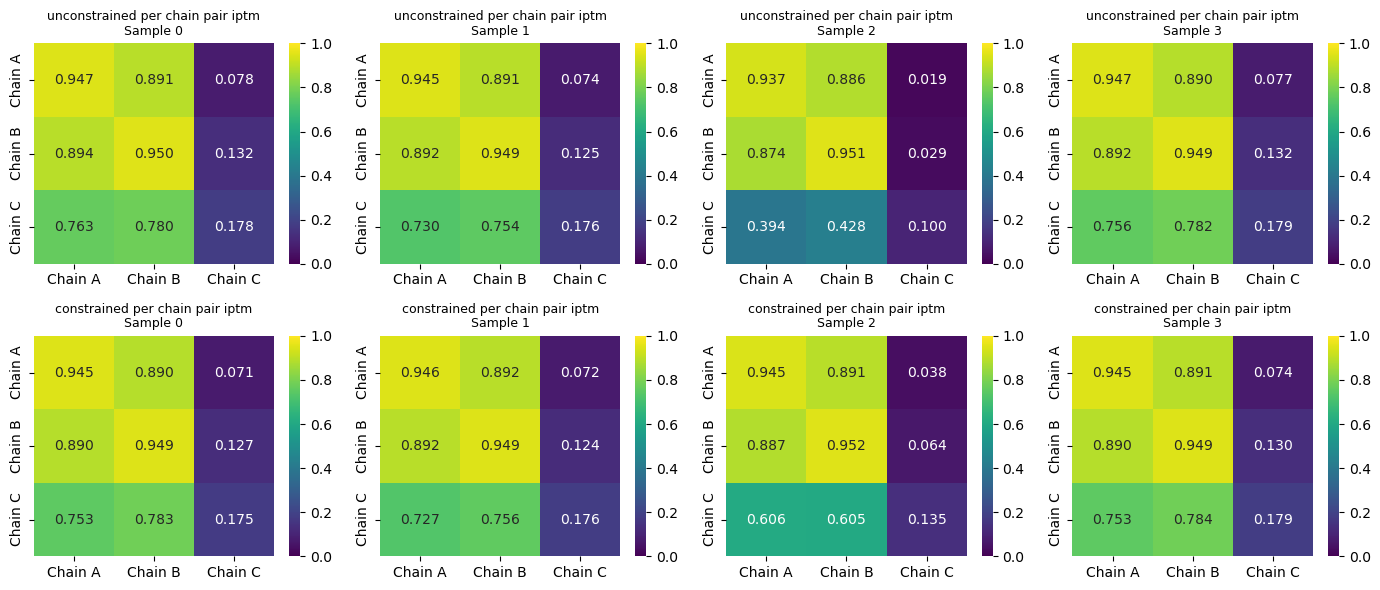

In [22]:
# Parse matrix strings from all 4 chai columns
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_matrix(x):
    if pd.isna(x):
        return None
    try:
        arr = np.array(ast.literal_eval(x))
        return arr.squeeze()  # remove extra dimensions
    except:
        return None

# Apply parse_matrix to all 4 columns
ptm_cols = ['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']

for col in ptm_cols:
    chai_df[f"{col}_matrix"] = chai_df[col].apply(parse_matrix)

# Create heatmaps for first 4 samples (focusing on pair_iptm columns)
pair_cols = ['chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_pair_iptm']

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for row_idx, col in enumerate(pair_cols):
    for sample_idx in range(4):
        ax = axes[row_idx, sample_idx]
        matrix = chai_df[f"{col}_matrix"].iloc[sample_idx]
        
        if matrix is not None and isinstance(matrix, np.ndarray) and matrix.ndim == 2:
            n = matrix.shape[0]  # works for 2x2, 3x3, etc.
            labels = [f'Chain {chr(65+i)}' for i in range(n)]  # A, B, C, ...
            
            sns.heatmap(
                matrix,
                ax=ax,
                cmap='viridis',
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                vmin=0,
                vmax=1,
                annot=True,
                fmt='.3f'
            )
            
            ax.set_title(
                f'{col.replace("chai_", "").replace("_", " ")}\nSample {sample_idx}',
                fontsize=9
            )
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])


plt.tight_layout()
plt.savefig(OUTPUT_DIR /'chai_matrices_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()



In [23]:
def extract_matrix_min(matrix):
    if matrix is None or not isinstance(matrix, np.ndarray) or matrix.ndim != 2:
        return np.nan

    n = matrix.shape[0]

    # germinal/mcmahon: only one interface (A-C or B-C)
    if n == 2:
        return np.min([matrix[0, 1], matrix[1, 0]])

    # snir: average C interactions with A and B
    elif n == 3:
        ac = np.min([matrix[0, 2], matrix[2, 0]])
        bc = np.min([matrix[1, 2], matrix[2, 1]])
        return np.min([ac, bc])

    return np.nan

chai_df['chai_unconstrained_per_chain_iptm'] = \
    chai_df['chai_unconstrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_min)

chai_df['chai_constrained_per_chain_iptm'] = \
    chai_df['chai_constrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_min)


# Display summary
print("Unconstrained A-B interface min (top 10):")
print(chai_df['chai_unconstrained_per_chain_iptm'].head(10).to_string())
print("\nConstrained A-B interface min (top 10):")
print(chai_df['chai_constrained_per_chain_iptm'].head(10).to_string())

Unconstrained A-B interface min (top 10):
0    0.077992
1    0.073652
2    0.019133
3    0.077001
4    0.077093
5    0.075082
6    0.055787
7    0.061475
8    0.014928
9    0.080386

Constrained A-B interface min (top 10):
0    0.071191
1    0.071804
2    0.037991
3    0.073952
4    0.073263
5    0.071724
6    0.071872
7    0.072929
8    0.072347
9    0.071848


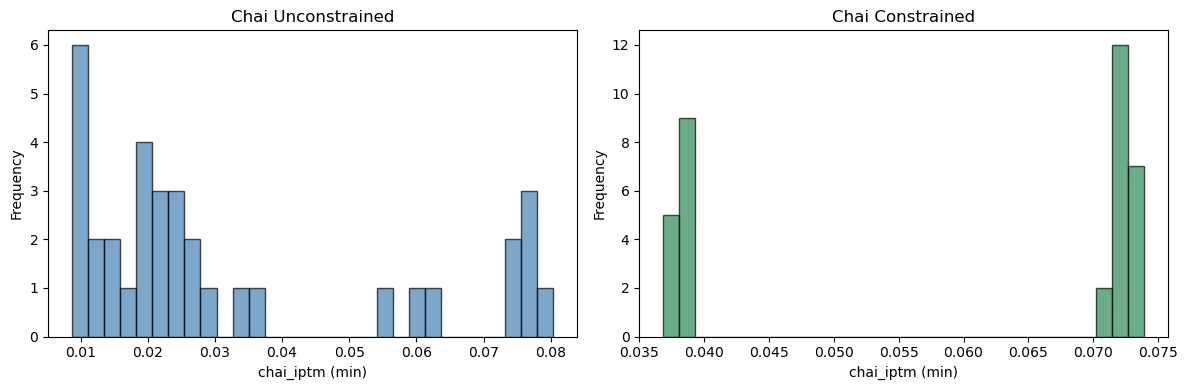

In [24]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_iptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_iptm (min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_iptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_iptm (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chai_iptm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Extract min pTM
def extract_ptm_min(arr):
    """Extract minimum of pTM array (average across both chains)"""
    if arr is None or not isinstance(arr, np.ndarray) or arr.ndim != 1:
        return np.nan
    return np.min(arr)

# Extract min for unconstrained pTM
chai_df['chai_unconstrained_per_chain_ptm'] = \
    chai_df['chai_unconstrained_per_chain_ptm_matrix'].apply(extract_ptm_min)

# Extract min for constrained pTM
chai_df['chai_constrained_per_chain_ptm'] = \
    chai_df['chai_constrained_per_chain_ptm_matrix'].apply(extract_ptm_min)

# Display summary

print("\nUnconstrained pTM min (top 10):")
print(chai_df['chai_unconstrained_per_chain_ptm'].head(10).to_string())
print("\nConstrained pTM min (top 10):")
print(chai_df['chai_constrained_per_chain_ptm'].head(10).to_string())
print(f"\nUnconstrained pTM min - desc stats:\n{chai_df['chai_unconstrained_per_chain_ptm'].describe()}")
print(f"\nConstrained pTM min - desc stats:\n{chai_df['chai_constrained_per_chain_ptm'].describe()}")


Unconstrained pTM min (top 10):
0    0.178244
1    0.175888
2    0.100218
3    0.178802
4    0.168942
5    0.178196
6    0.160372
7    0.164262
8    0.112114
9    0.174865

Constrained pTM min (top 10):
0    0.175172
1    0.175865
2    0.134584
3    0.178860
4    0.177383
5    0.172477
6    0.174929
7    0.176723
8    0.177111
9    0.176415

Unconstrained pTM min - desc stats:
count    35.000000
mean      0.117227
std       0.033312
min       0.088425
25%       0.094643
50%       0.099716
75%       0.139692
max       0.178802
Name: chai_unconstrained_per_chain_ptm, dtype: float64

Constrained pTM min - desc stats:
count    35.000000
mean      0.159923
std       0.019918
min       0.132804
25%       0.136316
50%       0.174867
75%       0.176053
max       0.178860
Name: chai_constrained_per_chain_ptm, dtype: float64


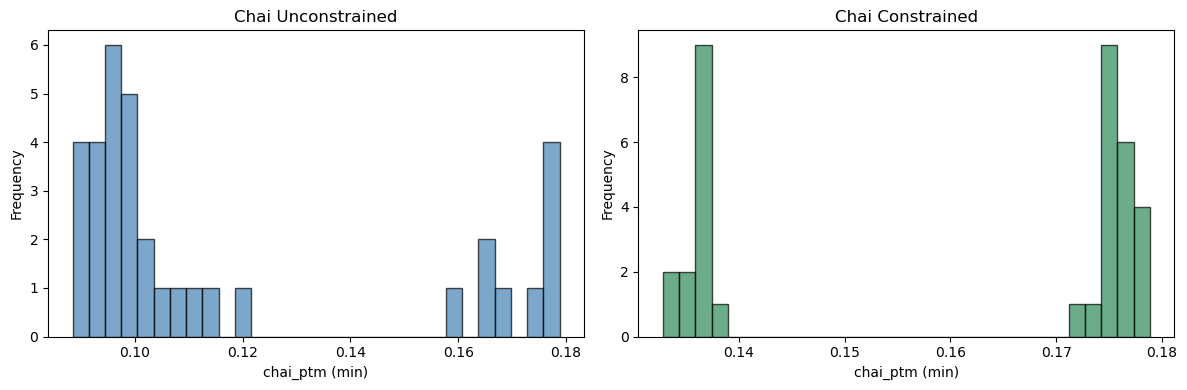

In [26]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_ptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_ptm (min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_ptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_ptm (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chai_ptm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Create df_chai_numeric with extracted mean scores 
df_chai_numeric = chai_df[['sample',
                            'chai_unconstrained_per_chain_ptm',
                            'chai_constrained_per_chain_ptm',
                            'chai_unconstrained_per_chain_iptm',
                            'chai_constrained_per_chain_iptm']].copy()

print("df_chai_numeric shape:", df_chai_numeric.shape)
print("\ndf_chai_numeric head:")
print(df_chai_numeric.head(10).to_string())
print("\ndf_chai_numeric info:")
print(df_chai_numeric.info())

# Save to CSV
df_chai_numeric.to_csv(OUTPUT_DIR / 'chai_numeric_metrics.csv', index=False)
print("\n✓ Saved to: chai_numeric_metrics.csv")

df_chai_numeric shape: (35, 5)

df_chai_numeric head:
                 sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_iptm  chai_constrained_per_chain_iptm
0          5ifj_abc_cut                          0.178244                        0.175172                           0.077992                         0.071191
1          5ig7_abc_cut                          0.175888                        0.175865                           0.073652                         0.071804
2          5ijk_acx_cut                          0.100218                        0.134584                           0.019133                         0.037991
3  5ifj_abc_cut_A_D111A                          0.178802                        0.178860                           0.077001                         0.073952
4  5ifj_abc_cut_A_K110A                          0.168942                        0.177383                           0.077093                         0.07326

In [28]:
scores_df.drop(columns=['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm'], inplace = True)
scores_df.head()

,source,type,sample,binder,KD[M],af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis
0,snir_ab,original,5ifj_abc_cut,1,0.000010,2.593883,95.404666,14.690,1.855,1.993750,...,0.986901,0.985055,0.985220,0.256930,0.278017,0.960036,0.937455,0.23935,0.96685,0.87115
1,snir_ab,original,5ig7_abc_cut,1,0.000100,2.572969,95.599717,8.050,1.025,2.020938,...,0.985429,0.987334,0.987299,0.258769,0.284754,0.952718,0.925141,0.23420,0.96935,0.85870
2,snir_ab,original,5ijk_acx_cut,1,0.000001,3.486349,92.439163,26.435,4.765,5.111071,...,0.986835,0.982311,0.979760,0.255680,0.283189,0.943557,0.906099,0.08775,0.92390,0.82455
3,snir_ab,alanine_scan,5ifj_abc_cut_A_D111A,0,NaN,2.815847,95.282854,13.225,1.745,2.100000,...,0.987563,0.979963,0.975488,0.256625,0.289870,0.943841,0.908519,0.21980,0.92900,0.85605
4,snir_ab,alanine_scan,5ifj_abc_cut_A_K110A,0,NaN,2.790728,94.871984,19.975,2.845,2.275417,...,0.987761,0.983894,0.983133,0.254981,0.275365,0.961354,0.939275,0.23650,0.96220,0.87810


In [29]:
# Join scores_df with df_chai_numeric on "sample"
scores_df_extended = scores_df.merge(df_chai_numeric, on='sample', how='left')

print("Joined DataFrame shape:", scores_df_extended.shape)
print("\nNew columns added from df_chai_numeric:")
new_cols = [col for col in scores_df_extended.columns if col in df_chai_numeric.columns and col != 'sample']
print(new_cols)
print("\nscores_df_extended head:")
print(scores_df_extended[['sample'] + new_cols].head(10).to_string())
print("\nJoin statistics:")
print(f"  - Total rows: {len(scores_df_extended)}")
print(f"  - Rows with all chai metrics: {scores_df_extended[new_cols].notna().all(axis=1).sum()}")
print(f"  - Rows with missing chai metrics: {scores_df_extended[new_cols].isna().any(axis=1).sum()}")

# Save extended dataframe
scores_df_extended.to_csv(OUTPUT_DIR / 'scores_df_extended_with_chai.csv', index=False)
print(f"\n✓ Saved to: {OUTPUT_DIR / 'scores_df_extended_with_chai.csv'}")

Joined DataFrame shape: (35, 90)

New columns added from df_chai_numeric:
['chai_unconstrained_per_chain_ptm', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_per_chain_iptm', 'chai_constrained_per_chain_iptm']

scores_df_extended head:
                 sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_iptm  chai_constrained_per_chain_iptm
0          5ifj_abc_cut                          0.178244                        0.175172                           0.077992                         0.071191
1          5ig7_abc_cut                          0.175888                        0.175865                           0.073652                         0.071804
2          5ijk_acx_cut                          0.100218                        0.134584                           0.019133                         0.037991
3  5ifj_abc_cut_A_D111A                          0.178802                        0.178860                           0.077001 

In [14]:
scores_df_extended.head()

,source,type,sample,binder,KD[M],af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm
0,snir_ab,original,5ifj_abc_cut,1,0.000010,2.593883,95.404666,14.690,1.855,1.993750,...,0.278017,0.960036,0.937455,0.23935,0.96685,0.87115,0.178244,0.175172,0.077992,0.071191
1,snir_ab,original,5ig7_abc_cut,1,0.000100,2.572969,95.599717,8.050,1.025,2.020938,...,0.284754,0.952718,0.925141,0.23420,0.96935,0.85870,0.175888,0.175865,0.073652,0.071804
2,snir_ab,original,5ijk_acx_cut,1,0.000001,3.486349,92.439163,26.435,4.765,5.111071,...,0.283189,0.943557,0.906099,0.08775,0.92390,0.82455,0.100218,0.134584,0.019133,0.037991
3,snir_ab,alanine_scan,5ifj_abc_cut_A_D111A,0,NaN,2.815847,95.282854,13.225,1.745,2.100000,...,0.289870,0.943841,0.908519,0.21980,0.92900,0.85605,0.178802,0.178860,0.077001,0.073952
4,snir_ab,alanine_scan,5ifj_abc_cut_A_K110A,0,NaN,2.790728,94.871984,19.975,2.845,2.275417,...,0.275365,0.961354,0.939275,0.23650,0.96220,0.87810,0.168942,0.177383,0.077093,0.073263


In [33]:
chai_debug = scores_df_extended[['sample', 'chai_unconstrained_per_chain_ptm', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_ptm', 'chai_constrained_ptm', 'chai_unconstrained_per_chain_iptm', 'chai_constrained_per_chain_iptm', 'chai_constrained_interface_iptm',  'chai_unconstrained_interface_iptm', 'chai_unconstrained_iptm', 'chai_constrained_iptm', 'chai_unconstrained_aggregate_score', 'chai_constrained_aggregate_score', 'chai_unconstrained_ipsae', 'chai_constrained_ipsae', 'chai_unconstrained_pdockq', 'chai_constrained_pdockq', 'chai_unconstrained_pdockq2', 'chai_constrained_pdockq2', 'chai_unconstrained_lis', 'chai_constrained_lis']]
chai_debug.head()

,sample,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_ptm,chai_constrained_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm,chai_constrained_interface_iptm,chai_unconstrained_interface_iptm,chai_unconstrained_iptm,...,chai_unconstrained_aggregate_score,chai_constrained_aggregate_score,chai_unconstrained_ipsae,chai_constrained_ipsae,chai_unconstrained_pdockq,chai_constrained_pdockq,chai_unconstrained_pdockq2,chai_constrained_pdockq2,chai_unconstrained_lis,chai_constrained_lis
0,5ifj_abc_cut,0.178244,0.175172,0.955380,0.953794,0.077992,0.071191,0.098856,0.105120,0.902341,...,0.912949,0.909936,0.732120,0.738736,0.20100,0.19890,0.88470,0.87800,0.74170,0.73795
1,5ig7_abc_cut,0.175888,0.175865,0.954180,0.954174,0.073652,0.071804,0.098019,0.099136,0.900288,...,0.911067,0.911063,0.676551,NaN,0.18585,NaN,0.89955,NaN,0.72005,NaN
2,5ijk_acx_cut,0.100218,0.134584,0.942485,0.952061,0.019133,0.037991,0.051007,0.023850,0.875411,...,0.888825,0.903500,0.198792,0.485237,0.04165,0.05920,0.15250,0.48090,0.40095,0.59255
3,5ifj_abc_cut_A_D111A,0.178802,0.178860,0.954573,0.953805,0.077001,0.073952,0.102178,0.104434,0.901102,...,0.911796,0.910263,0.733391,0.739803,0.19960,0.19605,0.89260,0.88500,0.74205,0.73510
4,5ifj_abc_cut_A_K110A,0.168942,0.177383,0.953871,0.953797,0.077093,0.073263,0.101700,0.099966,0.899702,...,0.910536,0.910136,0.688461,0.738376,0.17655,0.18720,0.87865,0.87965,0.72450,0.73235


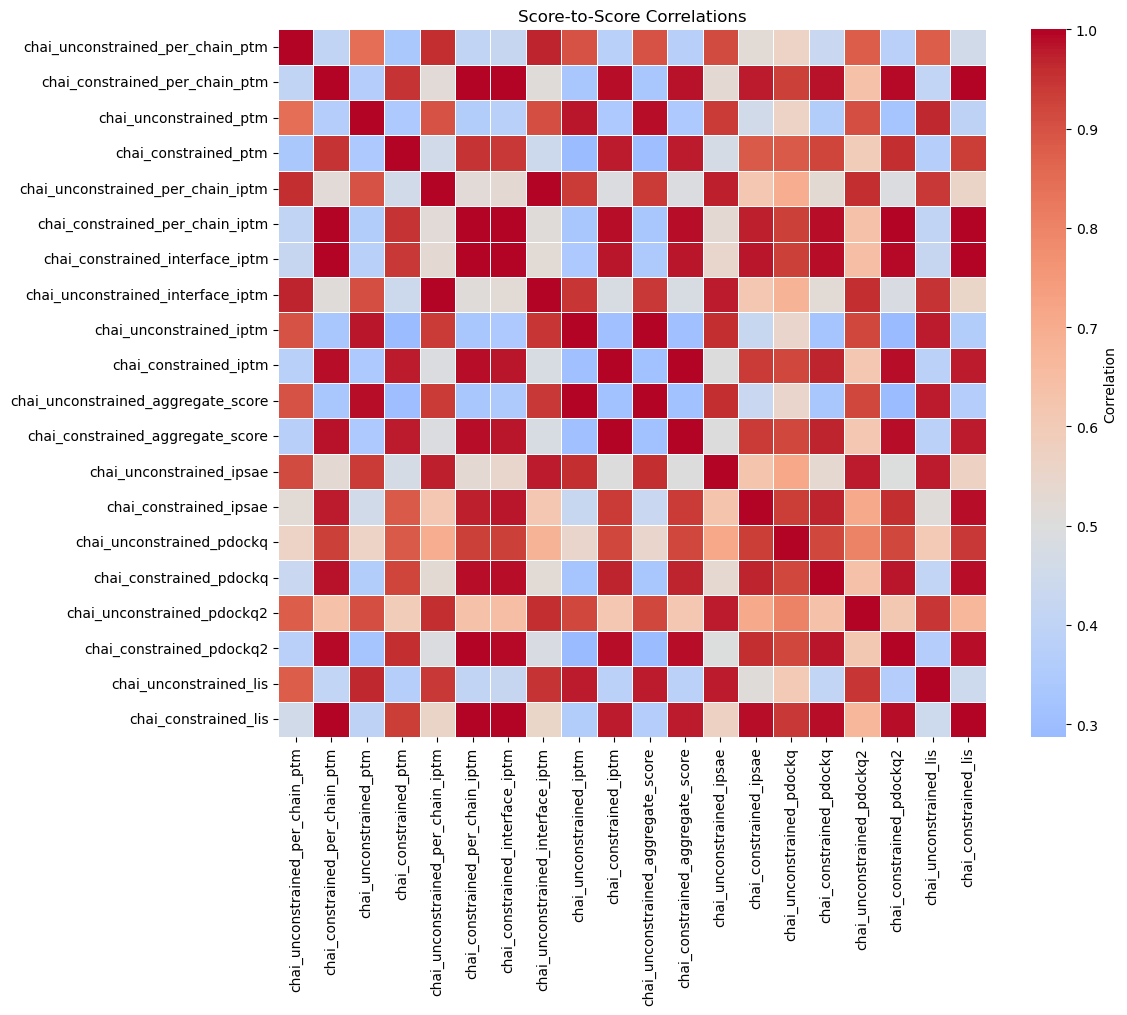

<Figure size 640x480 with 0 Axes>

In [35]:
# directions!!!!!
# Create numeric df and drop binder column
num_df = chai_debug.select_dtypes(include=[np.number])
num_df = num_df.dropna(axis=1, how='all')



# Calculate correlation matrix
correlation_matrix = num_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, fmt='.2f', cmap='coolwarm', 
            center=0.5, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Score-to-Score Correlations')
plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR / 'chai_correlation_heatmap.png', dpi=150, bbox_inches='tight')